In [1]:
!nvidia-smi

Mon Jun  1 05:07:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install numba kaggle

In [3]:
# enabling gpu
import torch

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import CIFAR10

In [5]:
# loading dataset
transform = transforms.ToTensor()

dataset = CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


In [6]:
# checking dataset information
print("Total Images:", len(dataset))
print("Classes:", dataset.classes)

Total Images: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
# checking datset structure
import os

for root, dirs, files in os.walk('./data'):
    print(root)

./data
./data/cifar-10-batches-py


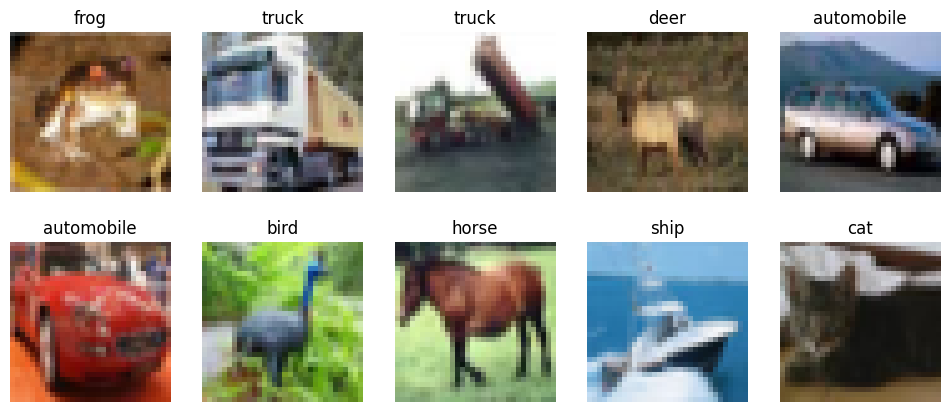

In [8]:
# displaying sample images
classes = dataset.classes

fig, axes = plt.subplots(2,5, figsize=(12,5))

for i in range(10):
    img, label = dataset[i]

    axes[i//5, i%5].imshow(
        np.transpose(img.numpy(), (1,2,0))
    )
    axes[i//5, i%5].set_title(classes[label])
    axes[i//5, i%5].axis('off')

plt.show()

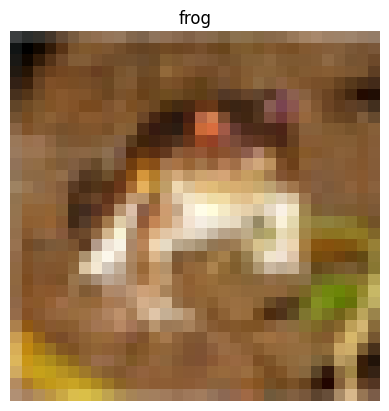

In [9]:
# selecting one image
img, label = dataset[0]

image = np.transpose(img.numpy(), (1,2,0))

plt.imshow(image)
plt.title(classes[label])
plt.axis('off')
plt.show()

In [10]:
# transfering image ot cuda
image_tensor = torch.tensor(
    image,
    dtype=torch.float32
).cuda()

print(image_tensor.device)

cuda:0


In [11]:
# cuda contrast enhancement function
def contrast_enhancement_cuda(image_tensor,
                              alpha=2.0):

    enhanced = alpha * (image_tensor - 0.5) + 0.5

    enhanced = torch.clamp(
        enhanced,
        0,
        1
    )

    return enhanced

In [12]:
# applying enhancement function
enhanced_gpu = contrast_enhancement_cuda(
    image_tensor,
    alpha=2.5
)

In [13]:
# moving back to cpu
enhanced_cpu = enhanced_gpu.cpu().numpy()

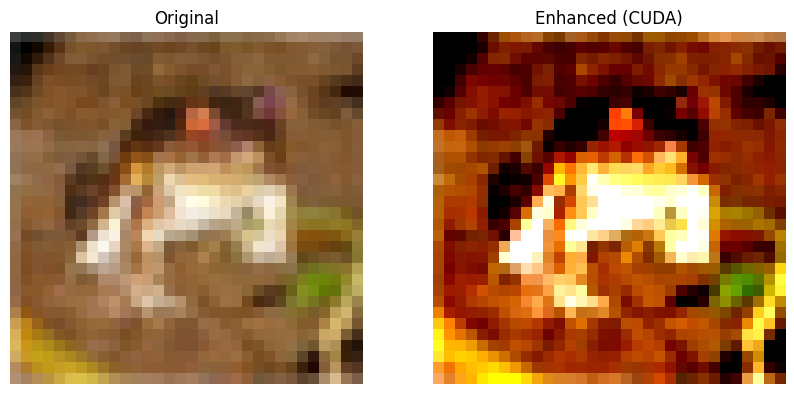

In [14]:
# comparing origional and enchanced image
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(enhanced_cpu)
plt.title("Enhanced (CUDA)")
plt.axis('off')

plt.show()

In [15]:
# processing multiple images using cuda
enhanced_images = []

for i in range(100):

    img,_ = dataset[i]

    img = np.transpose(
        img.numpy(),
        (1,2,0)
    )

    gpu_img = torch.tensor(
        img,
        dtype=torch.float32
    ).cuda()

    result = contrast_enhancement_cuda(
        gpu_img,
        alpha=2.5
    )

    enhanced_images.append(
        result.cpu().numpy()
    )

print("Processed:", len(enhanced_images))

Processed: 100


In [16]:
# time analysis ...cpu v/s CUDA
import time

img = torch.tensor(
    image,
    dtype=torch.float32
)

start = time.time()

for _ in range(1000):

    result = 2.5*(img-0.5)+0.5
    result = torch.clamp(result,0,1)

cpu_time = time.time()-start

print("CPU Time:", cpu_time)

CPU Time: 0.05516481399536133


In [17]:
# GPU time
gpu_img = torch.tensor(
    image,
    dtype=torch.float32
).cuda()

torch.cuda.synchronize()

start = time.time()

for _ in range(1000):

    result = 2.5*(gpu_img-0.5)+0.5
    result = torch.clamp(result,0,1)

torch.cuda.synchronize()

gpu_time = time.time()-start

print("GPU Time:", gpu_time)

GPU Time: 0.04473376274108887


In [18]:
# speedup
print(
    "Speedup:",
    cpu_time/gpu_time
)

Speedup: 1.2331807255885348


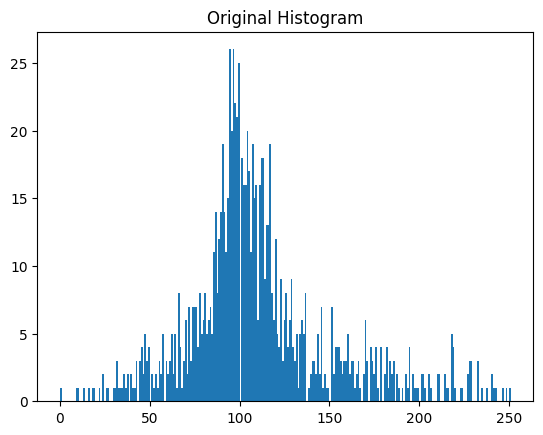

In [19]:
# histogram before enhancement
gray = cv2.cvtColor(
    (image*255).astype(np.uint8),
    cv2.COLOR_RGB2GRAY
)

plt.hist(
    gray.ravel(),
    bins=256
)

plt.title("Original Histogram")
plt.show()

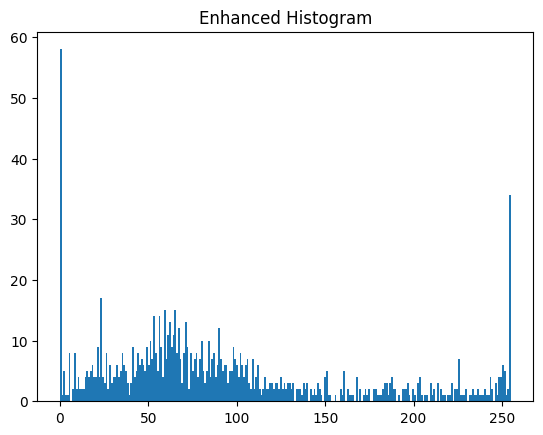

In [21]:
# histogram after enchancement
gray2 = cv2.cvtColor(
    (enhanced_cpu*255).astype(np.uint8),
    cv2.COLOR_RGB2GRAY
)

plt.hist(
    gray2.ravel(),
    bins=256
)

plt.title("Enhanced Histogram")
plt.show()

In [22]:
# final performance table
import pandas as pd

results = pd.DataFrame({

    "Method":["CPU","CUDA GPU"],
    "Execution Time":[
        cpu_time,
        gpu_time
    ]
})

results

,Method,Execution Time
0,CPU,0.055165
1,CUDA GPU,0.044734
